# Daily GTFS-RT TripUpdates transform sandbox

This notebook builds a daily job that condenses many realtime TripUpdates snapshots into one "latest prediction" record per trip-instance stop.

## End goal
Create a table-ready dataset with one row per:
- `trip instance` (trip/day/time context)
- `stop_sequence`

And keep only the most recent observed prediction (`snapshot_ts`) for each key.

## Steps
1. Configure day + bucket + agency.
2. Load snapshot blobs for that day.
3. Parse TripUpdates into a flat raw dataframe.
4. Build a trip-instance key.
5. Keep the latest observation per trip-instance + stop_sequence.
6. Run quality checks.
7. Export the final daily output.

In [6]:
from google.cloud import storage
from google.transit import gtfs_realtime_pb2
import pandas as pd
from tqdm.auto import tqdm

# ------------------------------
# Step 1: Daily run configuration
# ------------------------------
agency_id = "muni"
service_date = "2026-06-23"  # local service day this transform is for
bucket_name = "511_transit_data"
prefix = f"TripUpdates/{agency_id}/{service_date}/"

# Sampling controls for fast iteration.
# Set sample_mode = False for full-day runs.
sample_mode = False
sample_n_blobs = 400          # used when sample_mode=True
sample_every_k = None        # e.g., 10 to take every 10th blob

output_latest_parquet = f"trip_stop_prediction_latest_{agency_id}_{service_date}.parquet"
if sample_mode:
    output_latest_parquet = output_latest_parquet.replace(".parquet", f"_sample{sample_n_blobs}.parquet")

print(f"Agency: {agency_id}")
print(f"Service date: {service_date}")
print(f"Bucket: {bucket_name}")
print(f"Prefix: {prefix}")
print(f"Sample mode: {sample_mode}")
print(f"sample_n_blobs: {sample_n_blobs}")
print(f"sample_every_k: {sample_every_k}")

Agency: muni
Service date: 2026-06-23
Bucket: 511_transit_data
Prefix: TripUpdates/muni/2026-06-23/
Sample mode: False
sample_n_blobs: 400
sample_every_k: None


/Users/patri/miniconda3/envs/nachos/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


## Step 2 - Locate snapshots for full run or sample

We list all protobuf files under the daily GCS prefix, then optionally select a subset for faster iteration.

At parse time, we use GTFS-RT `feed.header.timestamp` as the primary `snapshot_ts`.
If header timestamp is missing, we fall back to a timestamp parsed from the filename.

In [7]:
def parse_snapshot_ts_from_blob_name(blob_name: str) -> pd.Timestamp:
    """Parse timestamp from blob name like .../2026-06-23T00-00-48.701503Z.pb"""
    ts_text = blob_name.rsplit("/", 1)[-1].replace(".pb", "")
    return pd.to_datetime(ts_text, format="%Y-%m-%dT%H-%M-%S.%fZ", utc=True, errors="coerce")


client = storage.Client()
blobs = list(client.list_blobs(bucket_name, prefix=prefix))

print(f"Found {len(blobs):,} blobs")
if not blobs:
    raise ValueError("No snapshot files found. Check bucket_name/prefix/service_date.")

blob_manifest = pd.DataFrame(
    {
        "blob_order": range(len(blobs)),
        "blob_name": [b.name for b in blobs],
    }
)
blob_manifest["filename_snapshot_ts"] = blob_manifest["blob_name"].map(parse_snapshot_ts_from_blob_name)

parse_manifest = blob_manifest.copy()
if sample_mode:
    if sample_every_k is not None and sample_every_k > 1:
        parse_manifest = parse_manifest.iloc[::sample_every_k].copy()
    parse_manifest = parse_manifest.head(sample_n_blobs).copy()

# Build iterable payload for parser cell.
parse_blob_orders = parse_manifest["blob_order"].tolist()
parse_blobs = [blobs[i] for i in parse_blob_orders]

print(f"Blobs selected for parse: {len(parse_blobs):,}")
print("Manifest preview (selected set):")
display(parse_manifest.head())
print("Missing filename timestamp parses (selected):", parse_manifest["filename_snapshot_ts"].isna().sum())

Found 1,440 blobs
Blobs selected for parse: 1,440
Manifest preview (selected set):


,blob_order,blob_name,filename_snapshot_ts
0,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:48.701503+00:00
1,1,TripUpdates/muni/2026-06-23/2026-06-23T00-01-5...,2026-06-23 00:01:56.462428+00:00
2,2,TripUpdates/muni/2026-06-23/2026-06-23T00-03-2...,2026-06-23 00:03:28.817101+00:00
3,3,TripUpdates/muni/2026-06-23/2026-06-23T00-04-0...,2026-06-23 00:04:07.279703+00:00
4,4,TripUpdates/muni/2026-06-23/2026-06-23T00-05-0...,2026-06-23 00:05:07.037219+00:00


Missing filename timestamp parses (selected): 0


## Step 3 - Parse protobuf TripUpdates into a flat raw table

This step creates one row per stop prediction observation from the selected blob set (`parse_blobs`).

If `sample_mode=True`, this runs on a small subset for fast iteration.

Key outputs at this stage:
- `trip_id`, `route_id`, `direction_id`
- `trip_start_date`, `trip_start_time` (if present)
- `stop_sequence`, `stop_id`
- prediction values (`arrival/departure` time and delay)
- `snapshot_ts` (from feed header when available, else filename fallback)
- `snapshot_ts_source` ("header" or "filename_fallback")

In [ ]:
'''
rows = []

for blob_order, blob in tqdm(
    zip(parse_blob_orders, parse_blobs),
    total=len(parse_blobs),
    desc="Parsing selected snapshots",
):
    feed = gtfs_realtime_pb2.FeedMessage()
    feed.ParseFromString(blob.download_as_bytes())

    filename_snapshot_ts = parse_snapshot_ts_from_blob_name(blob.name)
    header_snapshot_ts = pd.NaT

    if feed.HasField("header") and feed.header.HasField("timestamp"):
        header_snapshot_ts = pd.to_datetime(feed.header.timestamp, unit="s", utc=True, errors="coerce")

    if pd.notna(header_snapshot_ts):
        snapshot_ts = header_snapshot_ts
        snapshot_ts_source = "header"
    else:
        snapshot_ts = filename_snapshot_ts
        snapshot_ts_source = "filename_fallback"

    for entity in feed.entity:
        if not entity.HasField("trip_update"):
            continue

        tu = entity.trip_update
        trip = tu.trip

        trip_id = trip.trip_id if trip.trip_id else None
        route_id = trip.route_id if trip.route_id else None
        direction_id = trip.direction_id if trip.HasField("direction_id") else None
        trip_start_date = trip.start_date if trip.start_date else None  # GTFS-RT format YYYYMMDD
        trip_start_time = trip.start_time if trip.start_time else None  # GTFS-RT format HH:MM:SS

        for stu in tu.stop_time_update:
            stop_sequence = stu.stop_sequence if stu.HasField("stop_sequence") else None
            stop_id = stu.stop_id if stu.stop_id else None

            arrival_time = None
            departure_time = None
            arrival_delay_sec = None
            departure_delay_sec = None

            if stu.HasField("arrival"):
                if stu.arrival.HasField("time"):
                    arrival_time = pd.to_datetime(stu.arrival.time, unit="s", utc=True)
                if stu.arrival.HasField("delay"):
                    arrival_delay_sec = int(stu.arrival.delay)

            if stu.HasField("departure"):
                if stu.departure.HasField("time"):
                    departure_time = pd.to_datetime(stu.departure.time, unit="s", utc=True)
                if stu.departure.HasField("delay"):
                    departure_delay_sec = int(stu.departure.delay)

            # Keep rows only when we have enough identity to dedupe later.
            if trip_id and stop_sequence is not None and stop_id:
                rows.append(
                    {
                        "agency_id": agency_id,
                        "blob_order": blob_order,
                        "blob_name": blob.name,
                        "snapshot_ts": snapshot_ts,
                        "snapshot_ts_source": snapshot_ts_source,
                        "trip_id": trip_id,
                        "route_id": route_id,
                        "direction_id": direction_id,
                        "trip_start_date_raw": trip_start_date,
                        "trip_start_time": trip_start_time,
                        "stop_sequence": int(stop_sequence),
                        "stop_id": stop_id,
                        "arrival_time_predicted": arrival_time,
                        "departure_time_predicted": departure_time,
                        "arrival_delay_sec": arrival_delay_sec,
                        "departure_delay_sec": departure_delay_sec,
                    }
                )

df_raw = pd.DataFrame(rows)
print(f"Raw parsed rows: {len(df_raw):,}")
print(f"Parsed blobs: {len(parse_blobs):,} (sample_mode={sample_mode})")
print("snapshot_ts_source distribution:")
display(df_raw["snapshot_ts_source"].value_counts(dropna=False))
print("Rows with null snapshot_ts:", df_raw["snapshot_ts"].isna().sum())
display(df_raw.head())
'''

Parsing selected snapshots:   0%|          | 0/1440 [00:00<?, ?it/s]

In [8]:
import pandas as pd
from pathlib import Path

raw_dir = Path("../data/parquet/tripupdates_raw/muni_2026-06-23")
part_files = sorted(raw_dir.glob("part-*.parquet"))

if not part_files:
    raise ValueError(f"No parquet part files found in: {raw_dir}")

print(f"Found {len(part_files):,} parquet part files")
df_raw = pd.concat((pd.read_parquet(p) for p in part_files), ignore_index=True)
print(f"Loaded rows: {len(df_raw):,}")
df_raw.head()

Found 144 parquet part files
Loaded rows: 35,999,522


,agency_id,blob_order,blob_name,snapshot_ts,snapshot_ts_source,trip_id,route_id,direction_id,trip_start_date_raw,trip_start_date,trip_start_time,stop_sequence,stop_id,arrival_time_predicted,departure_time_predicted,arrival_delay_sec,departure_delay_sec
0,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053054_M41,1,0,20260622,2026-06-22,None,30,13896,2026-06-23 00:01:04+00:00,NaT,989.0,NaN
1,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053054_M41,1,0,20260622,2026-06-22,None,31,13852,2026-06-23 00:02:18+00:00,NaT,984.0,NaN
2,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053054_M41,1,0,20260622,2026-06-22,None,32,13845,2026-06-23 00:03:13+00:00,NaT,981.0,NaN
3,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053054_M41,1,0,20260622,2026-06-22,None,33,13822,2026-06-23 00:04:20+00:00,NaT,977.0,NaN
4,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053054_M41,1,0,20260622,2026-06-22,None,34,13824,2026-06-23 00:05:13+00:00,NaT,973.0,NaN


In [4]:
d = df_raw.sort_values('departure_time_predicted', ascending=False)
d['time_diff'] =d['departure_time_predicted']-d['latest_snapshot_ts']
d.sort_values('latest_snapshot_ts', ascending=True)#.head(20)

KeyError: 'latest_snapshot_ts'

## Step 4 - Build trip-instance key and normalize fields

Trip instance key for this notebook:
- `agency_id`
- `trip_id`
- `trip_start_date` (fallback to configured `service_date` if missing)
- `trip_start_time` (nullable)
- `direction_id` (nullable)

This is the key context used to prevent collisions between different runs of the same `trip_id`.

In [9]:
if df_raw.empty:
    raise ValueError("df_raw is empty. Upstream parse returned no rows.")

# Parse GTFS-RT start_date (YYYYMMDD) when present.
df_raw["trip_start_date"] = pd.to_datetime(
    df_raw["trip_start_date_raw"], format="%Y%m%d", errors="coerce"
).dt.date

# Fallback: if start_date missing, use configured service_date for this daily batch.
service_date_obj = pd.to_datetime(service_date).date()
df_raw["trip_start_date"] = df_raw["trip_start_date"].fillna(service_date_obj)

# Make sure timestamps are parsed consistently.
df_raw["snapshot_ts"] = pd.to_datetime(df_raw["snapshot_ts"], utc=True, errors="coerce")

print("Null checks in key components:")
key_nulls = df_raw[["agency_id", "trip_id", "trip_start_date", "stop_sequence"]].isna().sum()
display(key_nulls)

print("Rows with null snapshot_ts:", df_raw["snapshot_ts"].isna().sum())
print("snapshot_ts source counts:")
display(df_raw["snapshot_ts_source"].value_counts(dropna=False))

print("Unique counts:")
print("trip_id:", df_raw["trip_id"].nunique())
print("route_id:", df_raw["route_id"].nunique())
print("stop_id:", df_raw["stop_id"].nunique())

Null checks in key components:


agency_id          0
trip_id            0
trip_start_date    0
stop_sequence      0
dtype: int64

Rows with null snapshot_ts: 0
snapshot_ts source counts:


snapshot_ts_source
header    35999522
Name: count, dtype: int64

Unique counts:
trip_id: 10703
route_id: 69
stop_id: 3232


## Step 5 - Condense to one latest row per trip-instance stop

Grouping key for dedupe:
- `agency_id`, `trip_id`, `trip_start_date`, `trip_start_time`, `direction_id`, `stop_sequence`

Selection rule:
- keep the row with the max `snapshot_ts`
- tie-break with `blob_order` (later file wins if same timestamp)

In [10]:
trip_instance_stop_key = [
    "agency_id",
    "trip_id",
    "trip_start_date",
    "trip_start_time",
    "direction_id",
    "stop_sequence",
]

# Sort so the newest record per key is last.
df_latest = (
    df_raw.sort_values(["snapshot_ts", "blob_order", "blob_name"], ascending=[True, True, True])
    .drop_duplicates(subset=trip_instance_stop_key, keep="last")
    .copy()
)

df_latest = df_latest.rename(columns={"snapshot_ts": "latest_snapshot_ts"})

print(f"Raw rows: {len(df_raw):,}")
print(f"Latest rows: {len(df_latest):,}")
print(f"Rows removed by dedupe: {len(df_raw) - len(df_latest):,}")

# Quick anomaly check: same key mapping to multiple stop_ids in raw rows.
key_stop_check = (
    df_raw.groupby(trip_instance_stop_key, dropna=False)["stop_id"]
    .nunique()
    .reset_index(name="n_stop_ids")
)

multi_stop_key = key_stop_check.query("n_stop_ids > 1")
print(f"Keys with multiple stop_ids before dedupe: {len(multi_stop_key):,}")

display(df_latest.head())

Raw rows: 35,999,522
Latest rows: 376,283
Rows removed by dedupe: 35,623,239
Keys with multiple stop_ids before dedupe: 845


,agency_id,blob_order,blob_name,latest_snapshot_ts,snapshot_ts_source,trip_id,route_id,direction_id,trip_start_date_raw,trip_start_date,trip_start_time,stop_sequence,stop_id,arrival_time_predicted,departure_time_predicted,arrival_delay_sec,departure_delay_sec
0,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053054_M41,1,0,20260622,2026-06-22,None,30,13896,2026-06-23 00:01:04+00:00,NaT,989.0,NaN
19,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053055_M41,1,0,20260622,2026-06-22,None,30,13896,2026-06-23 00:01:14+00:00,NaT,399.0,NaN
38,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053056_M41,1,0,20260622,2026-06-22,None,26,13858,2026-06-23 00:01:06+00:00,NaT,102.0,NaN
39,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053056_M41,1,0,20260622,2026-06-22,None,27,13847,2026-06-23 00:02:00+00:00,NaT,85.0,NaN
61,muni,0,TripUpdates/muni/2026-06-23/2026-06-23T00-00-4...,2026-06-23 00:00:49+00:00,header,12053057_M41,1,0,20260622,2026-06-22,None,17,16297,2026-06-23 00:01:01+00:00,NaT,27.0,NaN


In [21]:
d = df_latest.sort_values('departure_time_predicted', ascending=False)
d['time_diff'] = d['arrival_time_predicted'] - d['latest_snapshot_ts']
d[~d['time_diff'].isna()].sort_values('time_diff', ascending=True)#.head(20)

,agency_id,blob_order,blob_name,latest_snapshot_ts,snapshot_ts_source,trip_id,route_id,direction_id,trip_start_date_raw,trip_start_date,trip_start_time,stop_sequence,stop_id,arrival_time_predicted,departure_time_predicted,arrival_delay_sec,departure_delay_sec,time_diff
1325438,muni,38,TripUpdates/muni/2026-06-23/2026-06-23T00-39-4...,2026-06-23 00:39:51+00:00,header,12058884_M41,9R,1,20260622,2026-06-22,None,30,15647,2026-06-23 00:39:14+00:00,NaT,23.0,NaN,-1 days +23:59:23
1328585,muni,38,TripUpdates/muni/2026-06-23/2026-06-23T00-39-4...,2026-06-23 00:39:51+00:00,header,12063970_M41,19,1,20260622,2026-06-22,None,16,17286,2026-06-23 00:39:14+00:00,NaT,-44.0,NaN,-1 days +23:59:23
1349924,muni,38,TripUpdates/muni/2026-06-23/2026-06-23T00-39-4...,2026-06-23 00:39:51+00:00,header,12085069_M41,N,0,20260622,2026-06-22,None,33,15215,2026-06-23 00:39:14+00:00,NaT,80.0,NaN,-1 days +23:59:23
1338771,muni,38,TripUpdates/muni/2026-06-23/2026-06-23T00-39-4...,2026-06-23 00:39:51+00:00,header,12072798_M41,38R,0,20260622,2026-06-22,None,10,14304,2026-06-23 00:39:15+00:00,NaT,-175.0,NaN,-1 days +23:59:24
1340722,muni,38,TripUpdates/muni/2026-06-23/2026-06-23T00-39-4...,2026-06-23 00:39:51+00:00,header,12074416_M41,44,0,20260622,2026-06-22,None,36,16408,2026-06-23 00:39:15+00:00,NaT,54.0,NaN,-1 days +23:59:24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17607846,muni,931,TripUpdates/muni/2026-06-23/2026-06-23T15-30-4...,2026-06-23 15:30:46+00:00,header,12086559_M11,PM,0,20260622,2026-06-22,None,8,16049,2026-06-23 22:46:28+00:00,NaT,-19.0,NaN,0 days 07:15:42
17607847,muni,931,TripUpdates/muni/2026-06-23/2026-06-23T15-30-4...,2026-06-23 15:30:46+00:00,header,12086559_M11,PM,0,20260622,2026-06-22,None,9,16073,2026-06-23 22:47:02+00:00,NaT,-18.0,NaN,0 days 07:16:16
17607848,muni,931,TripUpdates/muni/2026-06-23/2026-06-23T15-30-4...,2026-06-23 15:30:46+00:00,header,12086559_M11,PM,0,20260622,2026-06-22,None,10,16051,2026-06-23 22:47:52+00:00,NaT,-18.0,NaN,0 days 07:17:06
17607849,muni,931,TripUpdates/muni/2026-06-23/2026-06-23T15-30-4...,2026-06-23 15:30:46+00:00,header,12086559_M11,PM,0,20260622,2026-06-22,None,11,16059,2026-06-23 22:49:56+00:00,NaT,19.0,NaN,0 days 07:19:10


## Step 6 - Shape final table payload and export

This output is the dataset you can upsert into your `trip_stop_prediction_latest` table.

Suggested uniqueness in DB:
`(agency_id, trip_id, trip_start_date, trip_start_time, direction_id, stop_sequence)`

In [12]:
final_cols = [
    "agency_id",
    "trip_id",
    "trip_start_date",
    "trip_start_time",
    "route_id",
    "direction_id",
    "stop_sequence",
    "stop_id",
    "latest_snapshot_ts",
    "arrival_time_predicted",
    "departure_time_predicted",
    "arrival_delay_sec",
    "departure_delay_sec",
]

df_final = df_latest[final_cols].sort_values(
    ["trip_start_date", "trip_id", "stop_sequence"]
).reset_index(drop=True)

print(f"Final row count: {len(df_final):,}")
print("Final schema:")
print(df_final.dtypes)
display(df_final.head(20))

df_final.to_parquet(output_latest_parquet, index=False)
print(f"Saved final daily output: {output_latest_parquet}")

Final row count: 111,114
Final schema:
agency_id                                object
trip_id                                  object
trip_start_date                          object
trip_start_time                          object
route_id                                 object
direction_id                              int64
stop_sequence                             int64
stop_id                                  object
latest_snapshot_ts          datetime64[ns, UTC]
arrival_time_predicted      datetime64[ns, UTC]
departure_time_predicted    datetime64[ns, UTC]
arrival_delay_sec                       float64
departure_delay_sec                     float64
dtype: object


,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,departure_time_predicted,arrival_delay_sec,departure_delay_sec
0,muni,12052973_M41,2026-06-22,None,1,0,1,14015,2026-06-23 02:35:23+00:00,NaT,2026-06-23 02:36:27+00:00,NaN,87.0
1,muni,12052973_M41,2026-06-22,None,1,0,2,16294,2026-06-23 02:36:02+00:00,2026-06-23 02:36:06+00:00,NaT,17.0,NaN
2,muni,12052973_M41,2026-06-22,None,1,0,3,16290,2026-06-23 02:37:37+00:00,2026-06-23 02:37:27+00:00,NaT,49.0,NaN
3,muni,12052973_M41,2026-06-22,None,1,0,4,16314,2026-06-23 02:37:37+00:00,2026-06-23 02:38:04+00:00,NaT,64.0,NaN
4,muni,12052973_M41,2026-06-22,None,1,0,5,16307,2026-06-23 02:39:11+00:00,2026-06-23 02:39:29+00:00,NaT,85.0,NaN
5,muni,12052973_M41,2026-06-22,None,1,0,6,16302,2026-06-23 02:40:20+00:00,2026-06-23 02:40:36+00:00,NaT,88.0,NaN
6,muni,12052973_M41,2026-06-22,None,1,0,7,16299,2026-06-23 02:41:11+00:00,2026-06-23 02:41:20+00:00,NaT,74.0,NaN
7,muni,12052973_M41,2026-06-22,None,1,0,8,16316,2026-06-23 02:41:11+00:00,2026-06-23 02:42:10+00:00,NaT,76.0,NaN
8,muni,12052973_M41,2026-06-22,None,1,0,9,16312,2026-06-23 02:43:05+00:00,2026-06-23 02:43:10+00:00,NaT,70.0,NaN
9,muni,12052973_M41,2026-06-22,None,1,0,10,16315,2026-06-23 02:44:16+00:00,2026-06-23 02:44:51+00:00,NaT,105.0,NaN


Saved final daily output: trip_stop_prediction_latest_muni_2026-06-23_sample400.parquet


In [ ]:
d = df_final.sort_values('departure_time_predicted', ascending=False)
d['time_diff'] =d['departure_time_predicted']-d['latest_snapshot_ts']
d.sort_values('latest_snapshot_ts', ascending=True)#.head(20)

,agency_id,trip_id,trip_start_date,trip_start_time,route_id,direction_id,stop_sequence,stop_id,latest_snapshot_ts,arrival_time_predicted,departure_time_predicted,arrival_delay_sec,departure_delay_sec,time_diff
19833,muni,12059407_M41,2026-06-22,None,12,0,3,15851,2026-06-23 00:00:49+00:00,2026-06-23 00:01:10+00:00,NaT,400.0,NaN,NaT
48217,muni,12068990_M41,2026-06-22,None,30,1,18,15469,2026-06-23 00:00:49+00:00,2026-06-23 00:01:45+00:00,NaT,53.0,NaN,NaT
44706,muni,12068461_M41,2026-06-22,None,29,1,71,15311,2026-06-23 00:00:49+00:00,2026-06-23 00:01:47+00:00,NaT,-444.0,NaN,NaT
79886,muni,12078204_M41,2026-06-22,None,54,1,61,15113,2026-06-23 00:00:49+00:00,2026-06-23 00:00:59+00:00,NaT,-345.0,NaN,NaT
48216,muni,12068990_M41,2026-06-22,None,30,1,17,15472,2026-06-23 00:00:49+00:00,2026-06-23 00:00:53+00:00,NaT,53.0,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28338,muni,12064422_M41,2026-06-22,None,22,0,26,14618,2026-06-23 06:39:35+00:00,2026-06-23 07:07:14+00:00,NaT,86414.0,NaN,NaT
28337,muni,12064422_M41,2026-06-22,None,22,0,25,14632,2026-06-23 06:39:35+00:00,2026-06-23 07:06:18+00:00,NaT,86420.0,NaN,NaT
28336,muni,12064422_M41,2026-06-22,None,22,0,24,14622,2026-06-23 06:39:35+00:00,2026-06-23 07:04:59+00:00,NaT,86413.0,NaN,NaT
28352,muni,12064422_M41,2026-06-22,None,22,0,40,17866,2026-06-23 06:39:35+00:00,2026-06-23 07:24:10+00:00,NaT,86518.0,NaN,NaT


Prediction horizon (minutes) summary:
count    42594.000000
mean        61.633586
std         44.649760
min         10.016667
5%          13.416667
25%         29.733333
50%         54.500000
75%         83.400000
95%        121.439167
max        440.133333
Name: prediction_horizon_min, dtype: float64


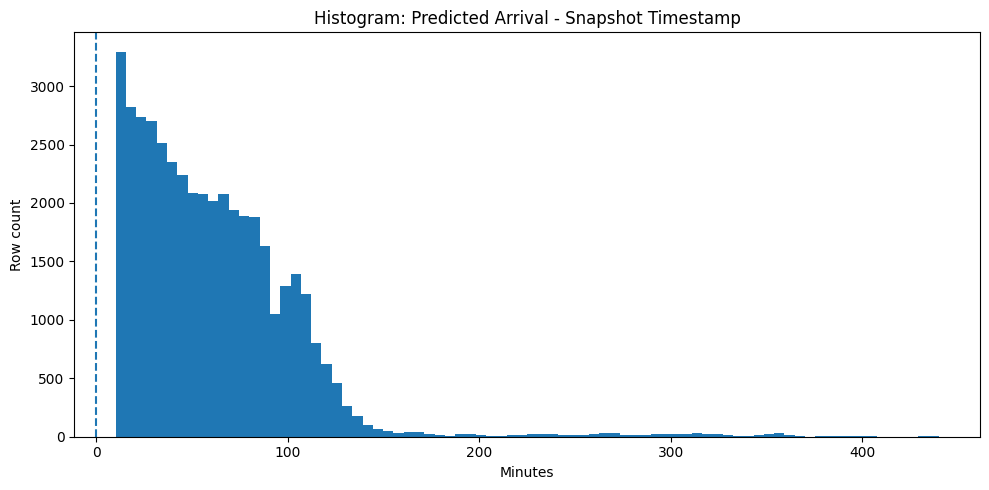

In [32]:
import matplotlib.pyplot as plt
from pathlib import Path

# Histogram of prediction horizon:
# predicted arrival time minus snapshot time (in minutes).
# Positive values mean the predicted arrival is in the future relative to snapshot.

# 1) Prefer existing df_final in memory.
# 2) Else, rebuild from df_raw if available.
# 3) Else, try loading saved final parquet.
if "df_final" not in globals() or df_final.empty:
    if "df_raw" in globals() and not df_raw.empty:
        print("df_final not in memory. Rebuilding from df_raw...")
        trip_instance_stop_key = [
            "agency_id",
            "trip_id",
            "trip_start_date",
            "trip_start_time",
            "direction_id",
            "stop_sequence",
        ]

        df_latest_tmp = (
            df_raw.sort_values(["snapshot_ts", "blob_order", "blob_name"], ascending=[True, True, True])
            .drop_duplicates(subset=trip_instance_stop_key, keep="last")
            .copy()
            .rename(columns={"snapshot_ts": "latest_snapshot_ts"})
        )

        final_cols = [
            "agency_id",
            "trip_id",
            "trip_start_date",
            "trip_start_time",
            "route_id",
            "direction_id",
            "stop_sequence",
            "stop_id",
            "latest_snapshot_ts",
            "arrival_time_predicted",
            "departure_time_predicted",
            "arrival_delay_sec",
            "departure_delay_sec",
        ]
        df_final = df_latest_tmp[final_cols].copy()
    else:
        saved_path = Path(f"trip_stop_prediction_latest_{agency_id}_{service_date}.parquet")
        if saved_path.exists():
            print(f"df_final not in memory. Loading from {saved_path}...")
            df_final = pd.read_parquet(saved_path)
        else:
            raise ValueError(
                "df_final is missing and could not be rebuilt/loaded. "
                "Run the load + transform cells first."
            )

h = df_final.copy()
h["prediction_horizon_min"] = (
    h["arrival_time_predicted"] - h["latest_snapshot_ts"]
).dt.total_seconds() / 60.0

# Keep non-null values for plotting.
h_valid = h[(h["prediction_horizon_min"].notna()) & (h["prediction_horizon_min"] > 10)].copy()

if h_valid.empty:
    raise ValueError("No non-null arrival_time_predicted values to plot.")

print("Prediction horizon (minutes) summary:")
print(h_valid["prediction_horizon_min"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]))

plt.figure(figsize=(10, 5))
plt.hist(h_valid["prediction_horizon_min"], bins=80)
plt.title("Histogram: Predicted Arrival - Snapshot Timestamp")
plt.xlabel("Minutes")
plt.ylabel("Row count")
plt.axvline(0, linestyle="--")
plt.tight_layout()
plt.show()

## Step 7 - Upsert notes for production

When loading `df_final` into your DB table:
- use the trip-instance-stop composite key as the conflict target
- update only when incoming `latest_snapshot_ts` is newer
- add a deterministic tie-breaker if equal timestamps

This keeps reruns idempotent and prevents stale rows from overwriting newer ones.

## Optional SQL template for the upsert

```sql
INSERT INTO trip_stop_prediction_latest (
  agency_id,
  trip_id,
  trip_start_date,
  trip_start_time,
  route_id,
  direction_id,
  stop_sequence,
  stop_id,
  latest_snapshot_ts,
  arrival_time_predicted,
  departure_time_predicted,
  arrival_delay_sec,
  departure_delay_sec
)
VALUES (...)
ON CONFLICT (agency_id, trip_id, trip_start_date, trip_start_time, direction_id, stop_sequence)
DO UPDATE SET
  route_id = EXCLUDED.route_id,
  stop_id = EXCLUDED.stop_id,
  latest_snapshot_ts = EXCLUDED.latest_snapshot_ts,
  arrival_time_predicted = EXCLUDED.arrival_time_predicted,
  departure_time_predicted = EXCLUDED.departure_time_predicted,
  arrival_delay_sec = EXCLUDED.arrival_delay_sec,
  departure_delay_sec = EXCLUDED.departure_delay_sec
WHERE
  EXCLUDED.latest_snapshot_ts > trip_stop_prediction_latest.latest_snapshot_ts;
```